# 4.5.1 TEXT PREPROCESSING

In [1]:
!pip install contractions wordcloud nltk gensim

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from collections import Counter
from wordcloud import WordCloud

import nltk
import contractions

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# TensorFlow / Keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.0 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load

train_df = pd.read_csv("/content/drive/MyDrive/Roro/train_movie_review.csv")
test_df = pd.read_csv("/content/drive/MyDrive/Roro/test_movie_review.csv")
val_df = pd.read_csv("/content/drive/MyDrive/Roro/val_movie_review.csv")

print(train_df.head())

   Unnamed: 0                                             review  sentiment
0        3774  Having avoided seeing the movie in the cinema,...          0
1       48396  With this movie I was really hoping that the i...          0
2        1980  Raymond Burr stars as an attorney caught up in...          0
3        6703  A lot people get hung up on this films tag as ...          1
4       28168  I was a fan of Buffy and hoped it would come t...          0


In [4]:
# Check column names

print(train_df.columns)

Index(['Unnamed: 0', 'review', 'sentiment'], dtype='object')


In [7]:
print(train_df[LABEL_COLUMN].unique())
print(test_df[LABEL_COLUMN].unique())
print(val_df[LABEL_COLUMN].unique())

[0 1]
[1 0]
[0 1]


In [6]:
TEXT_COLUMN = 'review'
LABEL_COLUMN = 'sentiment'

In [8]:
# Text cleaning

import re
import contractions

def clean_text(text):

    text = str(text)

    # lowercase
    text = text.lower()

    # expand contractions
    text = contractions.fix(text)

    # remove urls
    text = re.sub(r'http\S+|www\S+', '', text)

    # remove mentions/hashtags
    text = re.sub(r'@\w+|#\w+', '', text)

    # remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [9]:
# Apply cleaning
train_df['cleaned_review'] = train_df[TEXT_COLUMN].apply(clean_text)
test_df['cleaned_review'] = test_df[TEXT_COLUMN].apply(clean_text)
val_df['cleaned_review'] = val_df[TEXT_COLUMN].apply(clean_text)

print(train_df[['cleaned_review']].head())

                                      cleaned_review
0  having avoided seeing the movie in the cinema ...
1  with this movie i was really hoping that the i...
2  raymond burr stars as an attorney caught up in...
3  a lot people get hung up on this films tag as ...
4  i was a fan of buffy and hoped it would come t...


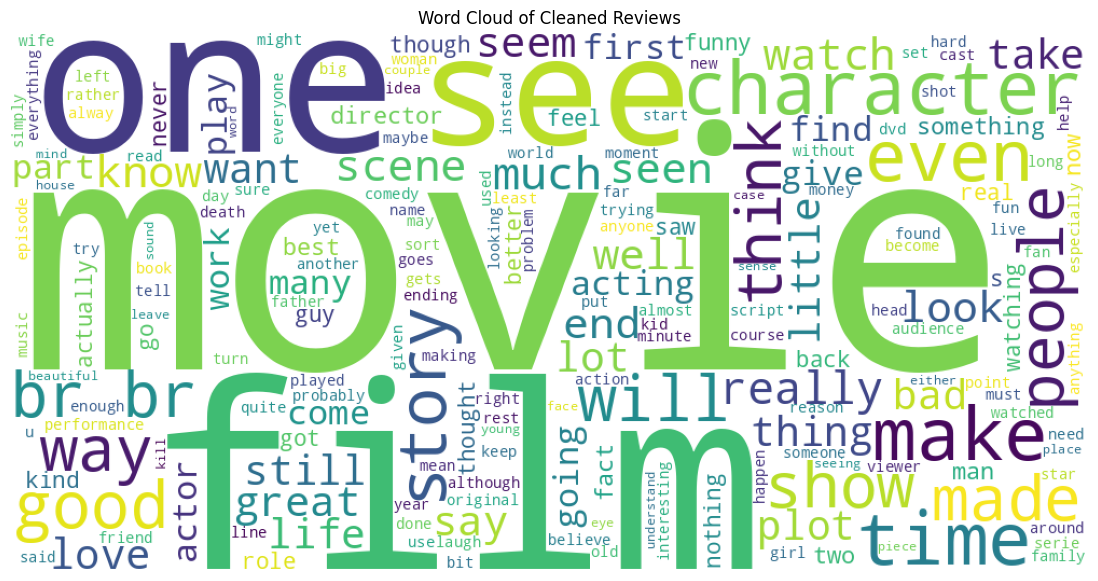

In [10]:
# VISUALIZATION - WORD CLOUD

all_words = " ".join(train_df['cleaned_review'])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(all_words)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Word Cloud of Cleaned Reviews")
plt.show()

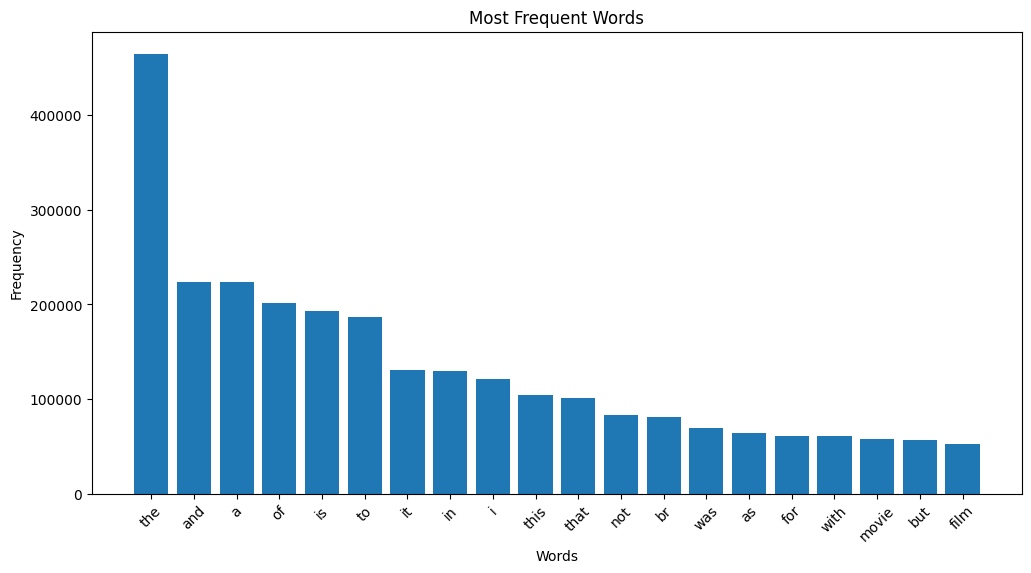

In [11]:
# MOST FREQUENT WORDS

words = all_words.split()

word_freq = Counter(words)

common_words = word_freq.most_common(20)

words_list = [i[0] for i in common_words]
freq_list = [i[1] for i in common_words]

plt.figure(figsize=(12,6))
plt.bar(words_list, freq_list)
plt.xticks(rotation=45)
plt.title("Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

In [12]:
# LABEL ENCODING

y_train = train_df['sentiment'].astype(int)
y_test = test_df['sentiment'].astype(int)
y_val = val_df['sentiment'].astype(int)

In [13]:
print(y_train.head())
print(np.isnan(y_train).sum())

0    0
1    0
2    0
3    1
4    0
Name: sentiment, dtype: int64
0


In [14]:
# TOKENIZATION

MAX_WORDS = 50000

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(train_df['cleaned_review'])

X_train_seq = tokenizer.texts_to_sequences(train_df['cleaned_review'])
X_test_seq = tokenizer.texts_to_sequences(test_df['cleaned_review'])
X_val_seq = tokenizer.texts_to_sequences(val_df['cleaned_review'])

In [15]:
# PERCENTILE BASED PADDING

review_lengths = [len(seq) for seq in X_train_seq]

max_len = int(np.percentile(review_lengths, 95))

X_train = pad_sequences(
    X_train_seq,
    maxlen=max_len,
    padding='post'
)

X_test = pad_sequences(
    X_test_seq,
    maxlen=max_len,
    padding='post'
)

X_val = pad_sequences(
    X_val_seq,
    maxlen=max_len,
    padding='post'
)

In [16]:
# TARGET VARIABLES

y_train = train_df[LABEL_COLUMN]
y_test = test_df[LABEL_COLUMN]
y_val = val_df[LABEL_COLUMN]

print(X_train.shape)
print(X_test.shape)
print(X_val.shape)

(35000, 590)
(10000, 590)
(5000, 590)


#4.5.2 Model Building and Training

##Model 1 — Simple RNN with Trainable Embedding Layer

In [17]:
# MODEL 1 - SIMPLE RNN

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    SimpleRNN,
    Dense,
    Dropout
)

vocab_size = MAX_WORDS
embedding_dim = 128

model1 = Sequential()

model1.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=max_len
    )
)

model1.add(SimpleRNN(128))

model1.add(Dropout(0.3))

model1.add(Dense(1, activation='sigmoid'))

model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

##Model 2 — LSTM with Trainable Embedding Layer

In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout,
    Bidirectional
)

from tensorflow.keras.optimizers import Adam

model2 = Sequential()

model2.add(
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=128,
        input_length=max_len
    )
)

# Faster LSTM
model2.add(
    Bidirectional(
        LSTM(64)
    )
)

model2.add(Dropout(0.5))

model2.add(Dense(1, activation='sigmoid'))

optimizer = Adam(learning_rate=0.001)

model2.compile(
    loss='binary_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

model2.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

##Model 3 — LSTM with Pretrained Word2Vec Embeddings

In [24]:
# MODEL 3 - WORD2VEC + LSTM

from gensim.models import Word2Vec

# Tokenize reviews into words
sentences = [
    review.split()
    for review in train_df['cleaned_review']
]

# Train Word2Vec model
word2vec_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

embedding_dim_w2v = 100

word_index = tokenizer.word_index

embedding_matrix = np.zeros(
    (vocab_size, embedding_dim_w2v)
)

for word, i in word_index.items():

    if i >= vocab_size:
        continue

    if word in word2vec_model.wv:
        embedding_matrix[i] = word2vec_model.wv[word]

from tensorflow.keras.layers import Embedding

model3 = Sequential()

model3.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim_w2v,
        weights=[embedding_matrix],
        input_length=max_len,
        trainable=False
    )
)

model3.add(LSTM(64))

model3.add(Dropout(0.5))

model3.add(Dense(1, activation='sigmoid'))

model3.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ ?                      │     5,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,000,000 (19.07 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 5,000,000 (19.07 MB)

#4.5.3 Model Training and Evaluation

In [37]:
# TRAINING CONFIGURATION
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [38]:
#Compile models
from tensorflow.keras.optimizers import Adam

optimizer = Adam(
    learning_rate=0.001,
    clipnorm=1.0
)

model1.compile(
    loss='binary_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

model2.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model3.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [27]:
# TRAIN MODEL 1

history1 = model1.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val, y_val),
)

Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 42s 69ms/step - accuracy: 0.4996 - loss: 0.7143 - val_accuracy: 0.5010 - val_loss: 0.6989
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 30s 54ms/step - accuracy: 0.5047 - loss: 0.7085 - val_accuracy: 0.4860 - val_loss: 0.6967
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 27s 49ms/step - accuracy: 0.5029 - loss: 0.6996 - val_accuracy: 0.4952 - val_loss: 0.6935
Epoch 4/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 27s 50ms/step - accuracy: 0.4989 - loss: 0.6961 - val_accuracy: 0.5044 - val_loss: 0.6965
Epoch 5/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step - accuracy: 0.4998 - loss: 0.6959 - val_accuracy: 0.4900 - val_loss: 0.6951
Epoch 6/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 27s 49ms/step - accuracy: 0.4984 - loss: 0.6954 - val_accuracy: 0.4916 - val_loss: 0.6982
Epoch 7/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - accuracy: 0.4992 - loss: 0.6957 - val_accuracy: 0.4970 - val_loss: 0.6947
Epoch 8/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 27s 49ms/step - accuracy: 0.5001 - loss: 0.6954 - 

In [39]:
# TRAIN MODEL 2

history2 = model2.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val, y_val),
)

Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 30s 48ms/step - accuracy: 0.7643 - loss: 0.4853 - val_accuracy: 0.8100 - val_loss: 0.4235
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 26s 48ms/step - accuracy: 0.8914 - loss: 0.2803 - val_accuracy: 0.8690 - val_loss: 0.3420
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 26s 48ms/step - accuracy: 0.9357 - loss: 0.1848 - val_accuracy: 0.8442 - val_loss: 0.3622
Epoch 4/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 26s 48ms/step - accuracy: 0.9568 - loss: 0.1275 - val_accuracy: 0.8452 - val_loss: 0.3940
Epoch 5/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 26s 47ms/step - accuracy: 0.9710 - loss: 0.0917 - val_accuracy: 0.8696 - val_loss: 0.4418
Epoch 6/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 26s 47ms/step - accuracy: 0.9805 - loss: 0.0666 - val_accuracy: 0.8742 - val_loss: 0.5164
Epoch 7/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.9699 - loss: 0.0915 - val_accuracy: 0.8736 - val_loss: 0.4903
Epoch 8/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 26s 47ms/step - accuracy: 0.9852 - loss: 0.0492 - 

In [40]:
# TRAIN MODEL 3

history3 = model3.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - accuracy: 0.5036 - loss: 0.6916 - val_accuracy: 0.5172 - val_loss: 0.6868
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.5157 - loss: 0.6832 - val_accuracy: 0.5030 - val_loss: 0.6859
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.5194 - loss: 0.6813 - val_accuracy: 0.5040 - val_loss: 0.6876
Epoch 4/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.5168 - loss: 0.6783 - val_accuracy: 0.5062 - val_loss: 0.6817
Epoch 5/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.5219 - loss: 0.6754 - val_accuracy: 0.5038 - val_loss: 0.6888
Epoch 6/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.6531 - loss: 0.5980 - val_accuracy: 0.7990 - val_loss: 0.4916
Epoch 7/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.7881 - loss: 0.5157 - val_accuracy: 0.7784 - val_loss: 0.5149
Epoch 8/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.7976 - loss: 0.5032 - 

##Visualization: Accuracy and Loss

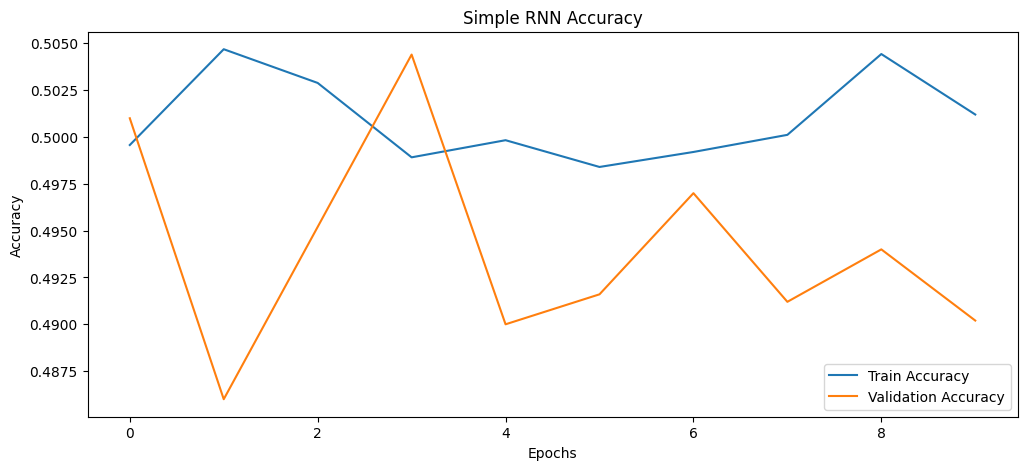

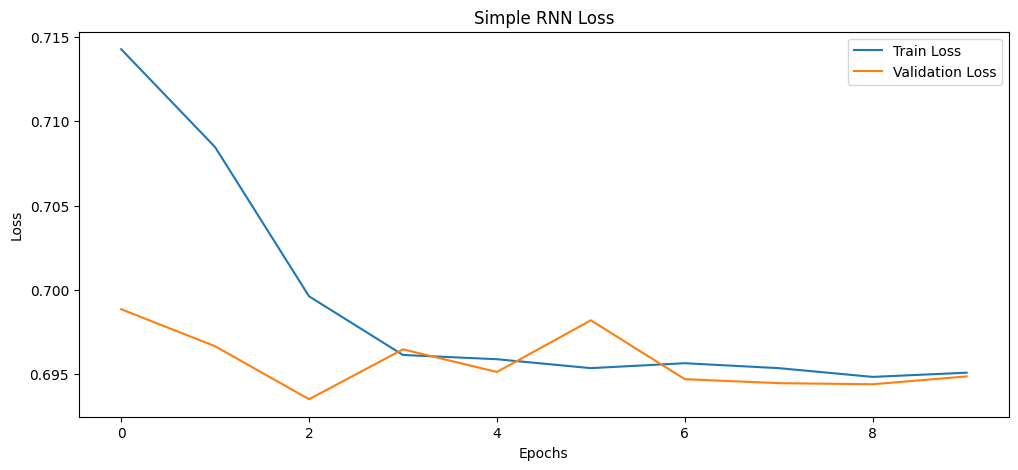

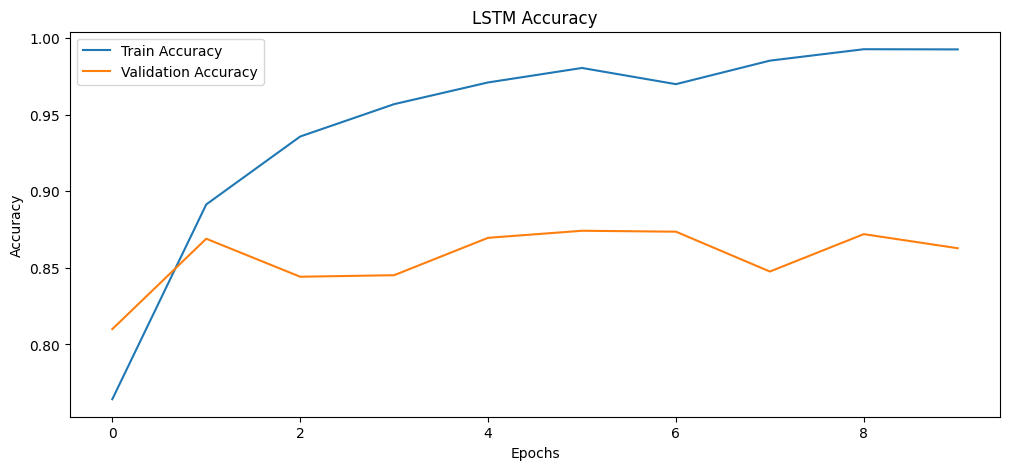

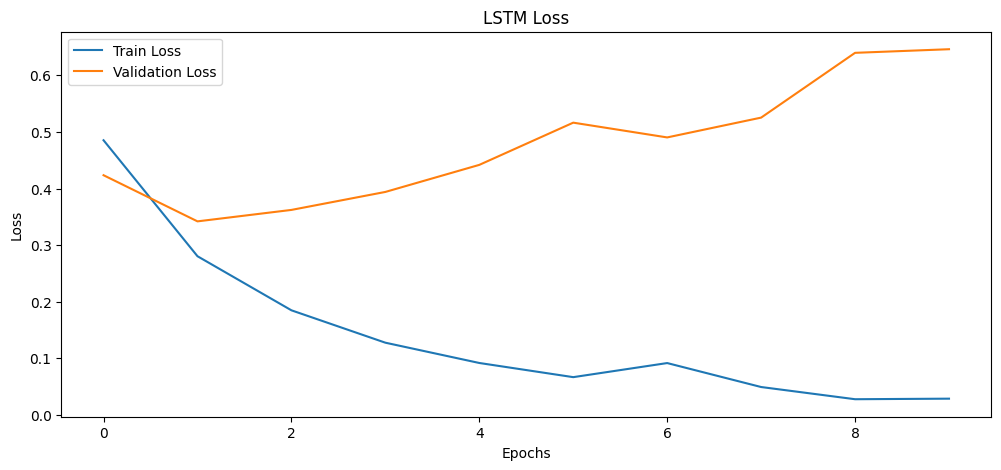

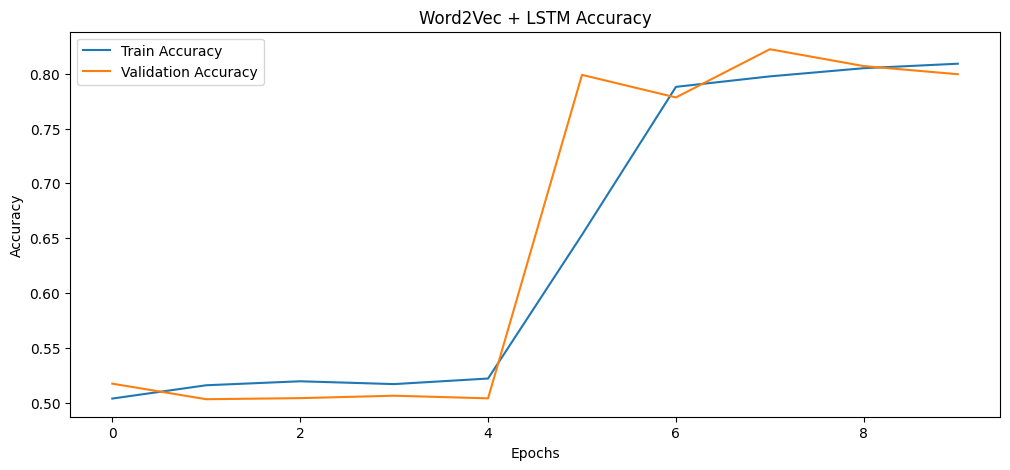

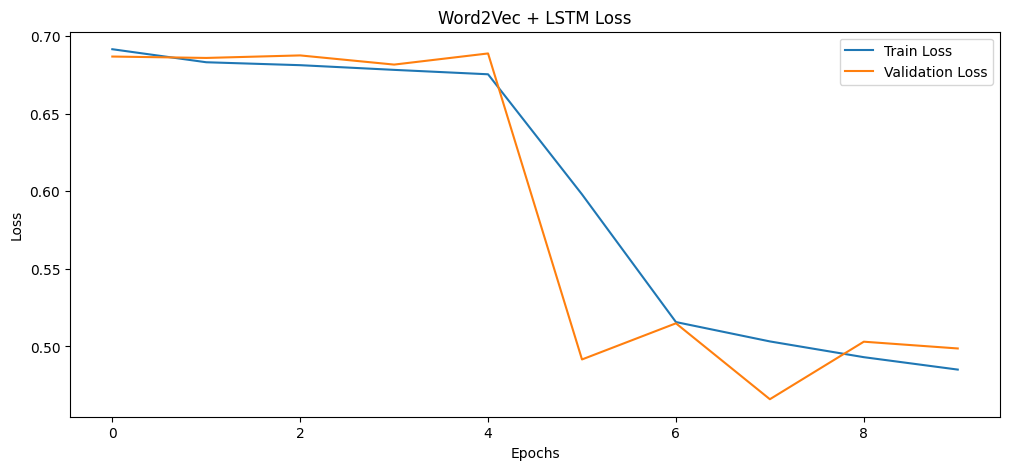

In [41]:
# Visualization Function

def plot_history(history, title):

    # Accuracy
    plt.figure(figsize=(12,5))

    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

    plt.title(title + " Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.show()

    # Loss
    plt.figure(figsize=(12,5))

    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')

    plt.title(title + " Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()

# Plot all models

plot_history(history1, "Simple RNN")
plot_history(history2, "LSTM")
plot_history(history3, "Word2Vec + LSTM")

##Evaluation Metrics

In [42]:
# EVALUATION

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

def evaluate_model(model, X_test, y_test, model_name):

    predictions = model.predict(X_test)

    predictions = (predictions > 0.5).astype(int)

    accuracy = accuracy_score(y_test, predictions)

    print("\n======================")
    print(model_name)
    print("======================")

    print("\nAccuracy:")
    print(accuracy)

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, predictions))

    print("\nClassification Report:")
    print(classification_report(y_test, predictions))

# Evaluate all models

evaluate_model(model1, X_test, y_test, "Simple RNN")

evaluate_model(model2, X_test, y_test, "LSTM")

evaluate_model(model3, X_test, y_test, "Word2Vec + LSTM")

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step

Simple RNN

Accuracy:
0.4962

Confusion Matrix:
[[4904   57]
 [4981   58]]

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.99      0.66      4961
           1       0.50      0.01      0.02      5039

    accuracy                           0.50     10000
   macro avg       0.50      0.50      0.34     10000
weighted avg       0.50      0.50      0.34     10000

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step

LSTM

Accuracy:
0.8662

Confusion Matrix:
[[4176  785]
 [ 553 4486]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.84      0.86      4961
           1       0.85      0.89      0.87      5039

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step

Word2Vec + LSTM

Accuracy

##Model Comparison

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


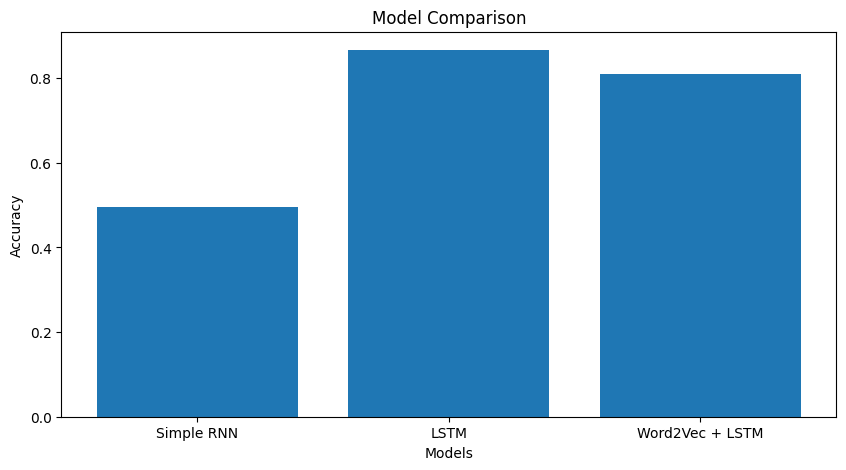

In [43]:
# MODEL COMPARISON

model_names = [
    "Simple RNN",
    "LSTM",
    "Word2Vec + LSTM"
]

accuracies = []

for model in [model1, model2, model3]:

    pred = model.predict(X_test)

    pred = (pred > 0.5).astype(int)

    acc = accuracy_score(y_test, pred)

    accuracies.append(acc)

plt.figure(figsize=(10,5))

plt.bar(model_names, accuracies)

plt.title("Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

#4.5.4 Error Analysis

In [44]:
# ERROR ANALYSIS

predictions = model2.predict(X_test)

predictions = (predictions > 0.5).astype(int)

predictions = predictions.flatten()

incorrect_indices = np.where(predictions != y_test)[0]

print("Number of incorrect predictions:", len(incorrect_indices))

#3 incorrect predictions

for i in incorrect_indices[:3]:

    print("\n====================")
    print("Review:")
    print(test_df.iloc[i][TEXT_COLUMN])

    print("\nActual Label:")
    print(y_test.iloc[i])

    print("\nPredicted Label:")
    print(predictions[i])

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step
Number of incorrect predictions: 1338

Review:
I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, this could have been one of the best Summerslam's ever if the WWF didn't have Lex Luger in the main event against Yokozuna, now for it's time it was ok to have a huge fat man vs a strong man but I'm glad times have changed. It was a terrible main event just like every match Luger is in is terrible. Other matches on the card were Razor Ramon vs Ted Dibiase, Steiner Brothers vs Heavenly Bodies, Shawn Michaels vs Curt Hening, this was the event where Shawn named his big monster of a body guard Diesel, IRS vs 1-2-3 Kid, Bret Hart first takes on Doink then takes on Jerry Lawler and stuff with the Harts and Lawler was always very interesting, then Ludvig Borga destroyed Marty Jannetty, Undertaker took on Giant Gonzalez in another terrible match, The Smoking G

##Possible Reasons for Error
###Reasons:

- Sarcasm is difficult for models to understand.

- Very long reviews may lose important context.

- Some reviews contain mixed sentiments.

- Limited vocabulary affects understanding.

###Model Complexity vs Performance:
- Simple RNN performs faster but struggles with long-term dependencies.
- LSTM performs better because it remembers long sequences.
- Word2Vec + LSTM improves semantic understanding through pretrained embeddings.

###Potential Improvements:

- Use Bidirectional LSTM.
- Use pretrained GloVe embeddings.
- Increase dataset size.
- Tune hyperparameters.
- Use Transformer-based models like BERT.

#4.5.5 GUI for Real-Time Prediction (Gradio)

In [45]:
# GRADIO GUI

# !pip install gradio

import gradio as gr

def predict_sentiment(text):

    cleaned = clean_text(text)

    seq = tokenizer.texts_to_sequences([cleaned])

    padded = pad_sequences(
        seq,
        maxlen=max_len,
        padding='post'
    )

    prediction = model2.predict(padded)[0][0]

    if prediction >= 0.5:
        return "Positive Review "
    else:
        return "Negative Review "

interface = gr.Interface(
    fn=predict_sentiment,
    inputs="text",
    outputs="text",
    title="IMDb Sentiment Analysis",
    description="Enter a movie review to predict sentiment."
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e07bfadc1e5e897a3b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
